<h1 style="text-align:center;">AF3 Motif Builder</h1>

In [2]:
import glob
import os
import shutil
import pandas as pd
import numpy as np
import pickle

import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product

from Bio.SeqUtils import seq1
from scipy.stats import spearmanr

from sklearn.decomposition import PCA
from Bio.PDB import MMCIFParser, PDBParser, PDBIO, MMCIFIO, Superimposer

# Build motif

/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_95793/4013882279.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(f'{step}_{peptide}/chainA_B_random_pair_{peptide}_output.txt', delim_whitespace=True)[['id', 'AF3_iptm_pair_mean']]
/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_95793/4013882279.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(f'{step}_{peptide}/chainA_B_random_pair_{peptide}_output.txt', delim_whitespace=True)[['id', 'AF3_iptm_pair_mean']]
/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_95793/4013882279.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(f'{step}_{peptide}/chainA_B_random_pair

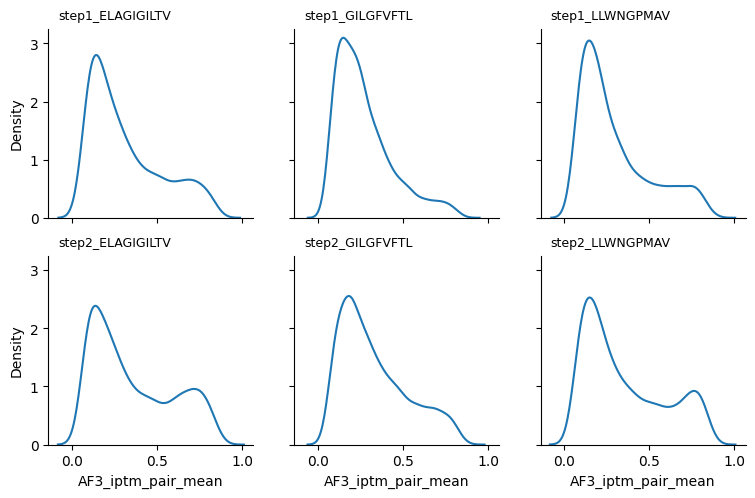

In [2]:
fig, axes = plt.subplots(2,3, figsize=(3*3,2.7*2), sharex=True, sharey=True)

steps = ['step1', 'step2']
peptides = ['ELAGIGILTV', 'GILGFVFTL', 'LLWNGPMAV']

for cnt1, step in enumerate(steps):
    for cnt2, peptide in enumerate(peptides):
        ax = axes[cnt1][cnt2]
        df = pd.read_csv(f'{step}_{peptide}/chainA_B_random_pair_{peptide}_output.txt', delim_whitespace=True)[['id', 'AF3_iptm_pair_mean']]

        sns.kdeplot(df, x='AF3_iptm_pair_mean', ax=ax)
        sns.despine()
        ax.text(0.05, 1.05, f'{step}_{peptide}', transform=ax.transAxes, fontsize=9)

/var/folders/mg/jhh2rvf11vd1jd013_6qqg200000gn/T/ipykernel_88919/585533433.py:10: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df1 = pd.read_csv(f'dummy_chains/{step}_dummy_{peptide}/chainA_dummyB/chainA_dummyB_pair_{peptide}_output.txt', delim_whitespace=True)[['id', 'AF3_iptm_pair_mean']]
/var/folders/mg/jhh2rvf11vd1jd013_6qqg200000gn/T/ipykernel_88919/585533433.py:11: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df2 = pd.read_csv(f'dummy_chains/{step}_dummy_{peptide}/dummyA_chainB/dummyA_chainB_pair_{peptide}_output.txt', delim_whitespace=True)[['id', 'AF3_iptm_pair_mean']]
/var/folders/mg/jhh2rvf11vd1jd013_6qqg200000gn/T/ipykernel_88919/585533433.py:10: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` in

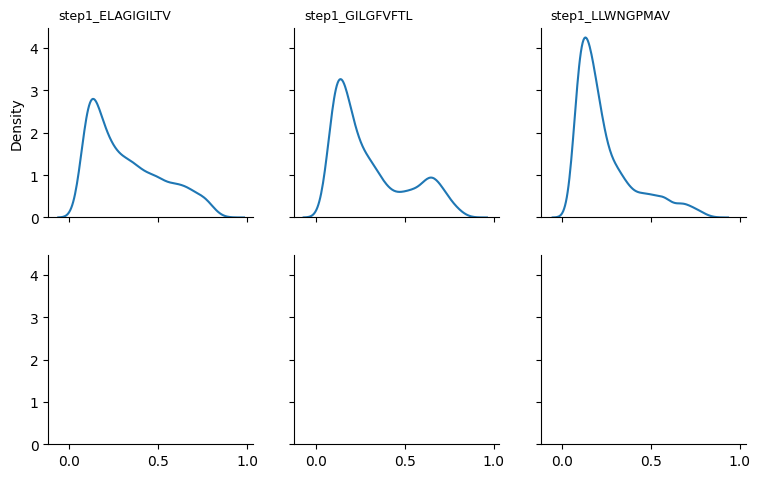

In [3]:
fig, axes = plt.subplots(2,3, figsize=(3*3,2.7*2), sharex=True, sharey=True)

steps = ['step1', 'step2']
steps = ['step1']
peptides = ['ELAGIGILTV', 'GILGFVFTL', 'LLWNGPMAV']

for cnt1, step in enumerate(steps):
    for cnt2, peptide in enumerate(peptides):
        ax = axes[cnt1][cnt2]
        df1 = pd.read_csv(f'dummy_chains/{step}_dummy_{peptide}/chainA_dummyB/chainA_dummyB_pair_{peptide}_output.txt', delim_whitespace=True)[['id', 'AF3_iptm_pair_mean']]
        df2 = pd.read_csv(f'dummy_chains/{step}_dummy_{peptide}/dummyA_chainB/dummyA_chainB_pair_{peptide}_output.txt', delim_whitespace=True)[['id', 'AF3_iptm_pair_mean']]

        df = pd.concat([df1, df2])
        sns.kdeplot(df, x='AF3_iptm_pair_mean', ax=ax)
        sns.despine()
        ax.text(0.05, 1.05, f'{step}_{peptide}', transform=ax.transAxes, fontsize=9)

In [3]:
# prepaire csv for motif building
steps = {'step1':0.5,
        'step2':0.8}

peptides = ['ELAGIGILTV', 'GILGFVFTL', 'LLWNGPMAV']

for step, threshold in steps.items():
    for peptide in peptides:
        df = pd.read_csv(f'{step}_{peptide}/chainA_B_random_pair_{peptide}_output.txt', delim_whitespace=True)[['id', 'AF3_iptm_pair_mean']]
        anno = pd.read_csv(f'{step}_{peptide}/chainA_B_random_pair_{peptide}_input.txt', delim_whitespace=True)

        df = pd.merge(df, anno, on='id')
        df.to_csv(f'{step}_{peptide}/baseline.txt', sep="\t", index=False)
            
        df = df[df['AF3_iptm_pair_mean'] > threshold]
        df['model'] = peptide
        df.to_csv(f'{step}_{peptide}/model.txt', sep="\t", index=False) 
        df.to_csv(f'{step}_{peptide}/model.csv', index=False) 

/var/folders/mg/jhh2rvf11vd1jd013_6qqg200000gn/T/ipykernel_96727/4140471201.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(f'{step}_{peptide}/chainA_B_random_pair_{peptide}_output.txt', delim_whitespace=True)[['id', 'AF3_iptm_pair_mean']]
/var/folders/mg/jhh2rvf11vd1jd013_6qqg200000gn/T/ipykernel_96727/4140471201.py:10: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  anno = pd.read_csv(f'{step}_{peptide}/chainA_B_random_pair_{peptide}_input.txt', delim_whitespace=True)
/var/folders/mg/jhh2rvf11vd1jd013_6qqg200000gn/T/ipykernel_96727/4140471201.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(f'{step}_{peptide}/chainA_B_random_pair_{peptide}_output.txt', deli

In [5]:
# prepaire csv for motif building
steps = {'step1':0.5,
        'step2':0.8}

steps = {'step1':0.5}
peptides = ['ELAGIGILTV', 'GILGFVFTL', 'LLWNGPMAV']
chains = ['chainA_dummyB', 'dummyA_chainB']

for step, threshold in steps.items():
    for peptide in peptides:
        lst = []
        for chain in chains:
            df = pd.read_csv(f'dummy_chains/{step}_dummy_{peptide}/{chain}/{chain}_pair_{peptide}_output.txt', delim_whitespace=True)[['id', 'AF3_iptm_pair_mean']]
            anno = pd.read_csv(f'dummy_chains/{step}_dummy_{peptide}/{chain}/{chain}_pair_{peptide}_input.txt', delim_whitespace=True)
            df = pd.merge(df, anno, on='id')

            df.to_csv(f'dummy_chains/{step}_dummy_{peptide}/{chain}/baseline.txt', sep="\t", index=False)
                
            df = df[df['AF3_iptm_pair_mean'] > threshold]
            df['model'] = peptide
            lst.append(df)

        df = pd.concat(lst)

        df.to_csv(f'dummy_chains/{step}_dummy_{peptide}/model.txt', sep="\t", index=False) 
        df.to_csv(f'dummy_chains/{step}_dummy_{peptide}/model.csv', index=False) 

/var/folders/mg/jhh2rvf11vd1jd013_6qqg200000gn/T/ipykernel_96727/2530590308.py:13: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(f'dummy_chains/{step}_dummy_{peptide}/{chain}/{chain}_pair_{peptide}_output.txt', delim_whitespace=True)[['id', 'AF3_iptm_pair_mean']]
/var/folders/mg/jhh2rvf11vd1jd013_6qqg200000gn/T/ipykernel_96727/2530590308.py:14: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  anno = pd.read_csv(f'dummy_chains/{step}_dummy_{peptide}/{chain}/{chain}_pair_{peptide}_input.txt', delim_whitespace=True)
/var/folders/mg/jhh2rvf11vd1jd013_6qqg200000gn/T/ipykernel_96727/2530590308.py:13: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(f'dummy_chains/{step}_dummy

# Motif accuracy

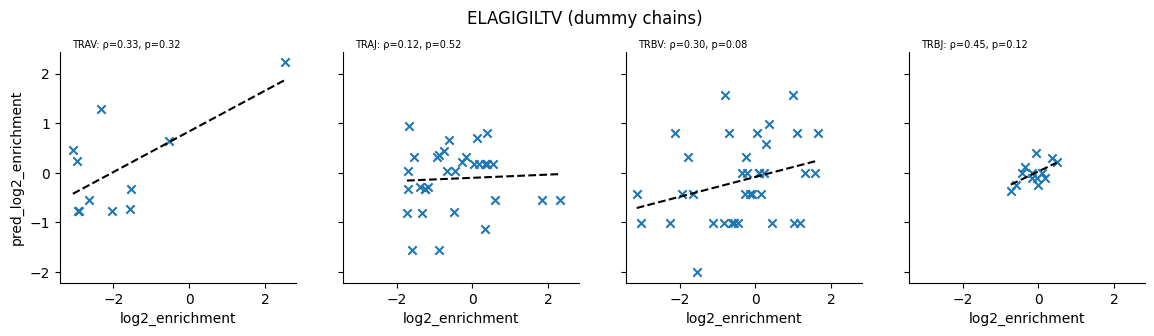

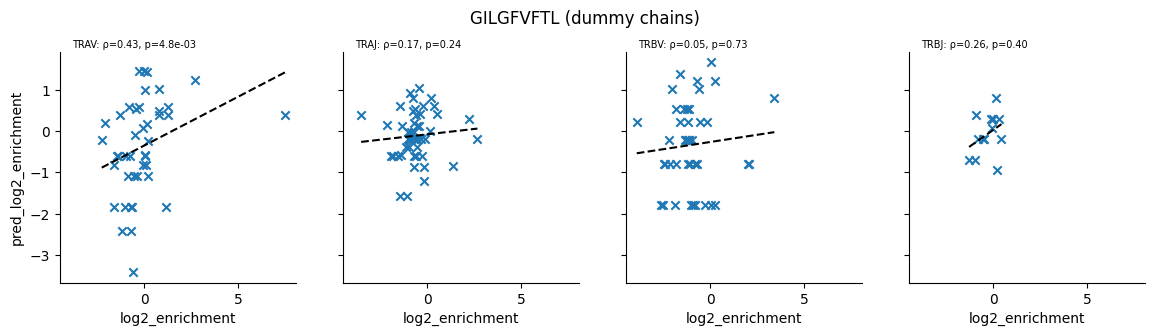

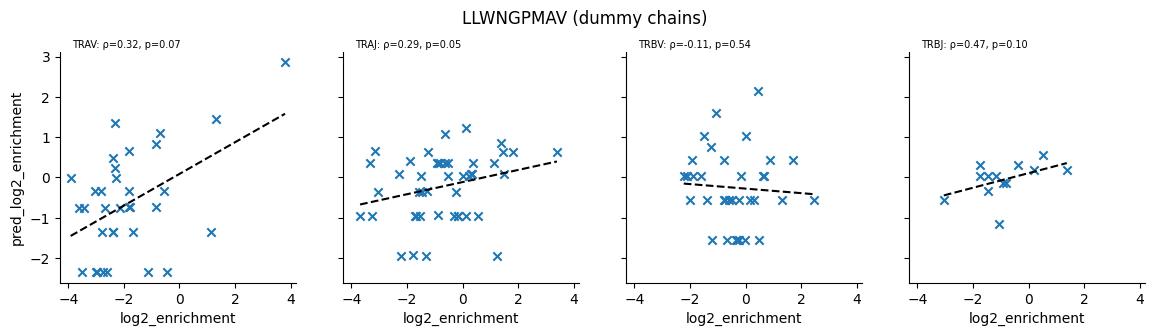

In [8]:
step = 'step1'
peptides = ['ELAGIGILTV', 'GILGFVFTL', 'LLWNGPMAV']
chains = ['chainA_dummyB', 'dummyA_chainB']
segments = ['TRAV', 'TRAJ', 'TRBV', 'TRBJ']

for peptide in peptides:
    ground_truth = pd.read_csv(f'{peptide}/enrichment.csv')[['segment', 'gene', 'log2_enrichment', 'rank']]

    lst = []
    for chain in chains:
        df = pd.read_csv(f'dummy_chains/{step}_dummy_{peptide}/{chain}/enrichment.csv')
        lst.append(df)

    df = pd.concat(lst)
    df = df[['gene', 'log2_enrichment', 'rank']]
    df = df.rename(columns={'log2_enrichment': 'pred_log2_enrichment', 'rank': 'pred_rank'})

    df = pd.merge(ground_truth, df, on='gene')

    fig, axes = plt.subplots(1, 4, figsize=(14, 3), sharex=True, sharey=True)

    for ax, segment in zip(axes, segments):
        df_seg = df[df['segment'] == segment]

        sns.scatterplot(df_seg, x='log2_enrichment', y='pred_log2_enrichment',
                        marker='x', linewidth=1.5, ax=ax)

        rho, pval = spearmanr(df_seg['log2_enrichment'], df_seg['pred_log2_enrichment'])

        sns.regplot(x=df_seg['log2_enrichment'], y=df_seg['pred_log2_enrichment'],
                    ax=ax, scatter=False, color='black',
                    line_kws={'lw': 1.5, 'ls': '--'}, ci=False)

        p_str = f"{pval:.1e}" if pval < 0.01 else f"{pval:.2f}"

        ax.text(0.05, 1.05, f"{segment}: ρ={rho:.2f}, p={p_str}",
                transform=ax.transAxes, fontsize=7, verticalalignment='top')


    fig.suptitle(f'{peptide} (dummy chains)', y=1.02)
    sns.despine()
    plt.show()

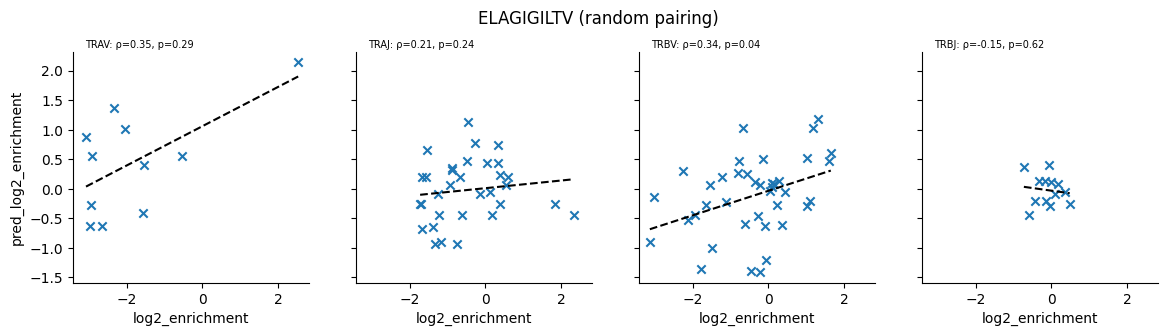

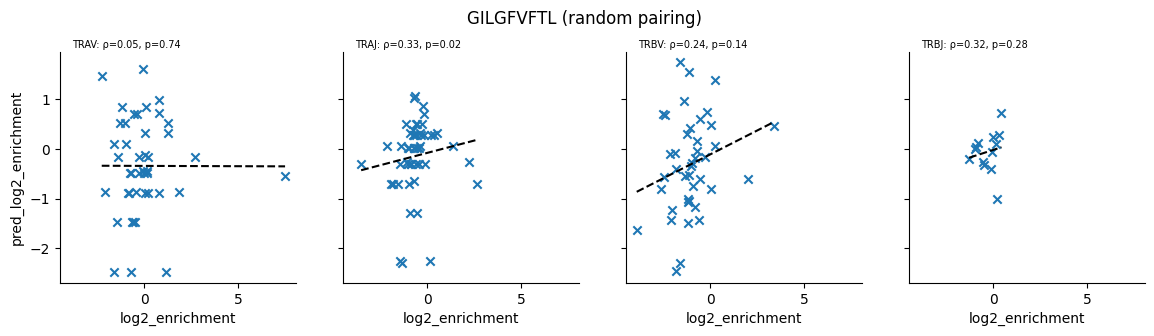

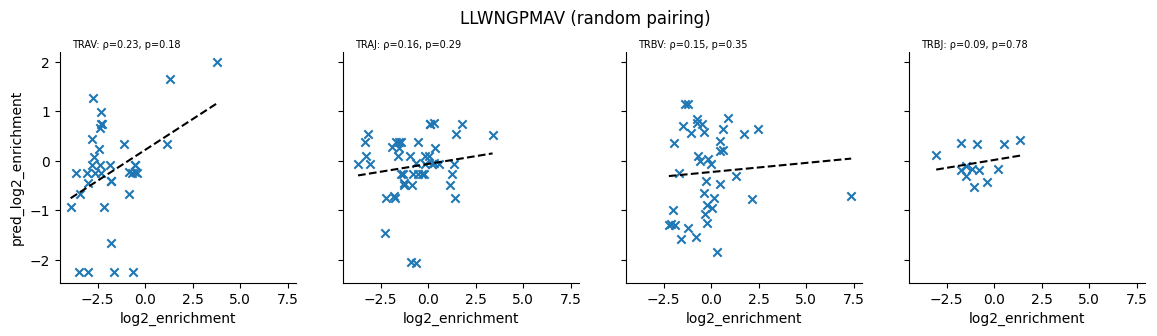

In [12]:
step = 'step1'
peptides = ['ELAGIGILTV', 'GILGFVFTL', 'LLWNGPMAV']
segments = ['TRAV', 'TRAJ', 'TRBV', 'TRBJ']

for peptide in peptides:
    ground_truth = pd.read_csv(f'{peptide}/enrichment.csv')[['segment', 'gene', 'log2_enrichment', 'rank']]

    df = pd.read_csv(f'{step}_{peptide}/enrichment.csv')
    df = df[['gene', 'log2_enrichment', 'rank']]
    df = df.rename(columns={'log2_enrichment': 'pred_log2_enrichment', 'rank': 'pred_rank'})

    df = pd.merge(ground_truth, df, on='gene')

    fig, axes = plt.subplots(1, 4, figsize=(14, 3), sharex=True, sharey=True)

    for ax, segment in zip(axes, segments):
        df_seg = df[df['segment'] == segment]

        sns.scatterplot(df_seg, x='log2_enrichment', y='pred_log2_enrichment',
                        marker='x', linewidth=1.5, ax=ax)

        rho, pval = spearmanr(df_seg['log2_enrichment'], df_seg['pred_log2_enrichment'])

        sns.regplot(x=df_seg['log2_enrichment'], y=df_seg['pred_log2_enrichment'],
                    ax=ax, scatter=False, color='black',
                    line_kws={'lw': 1.5, 'ls': '--'}, ci=False)

        p_str = f"{pval:.1e}" if pval < 0.01 else f"{pval:.2f}"

        ax.text(0.05, 1.05, f"{segment}: ρ={rho:.2f}, p={p_str}",
                transform=ax.transAxes, fontsize=7, verticalalignment='top')

    fig.suptitle(f'{peptide} (random pairing)', y=1.02)
    sns.despine()
    plt.show()

# PCA of CDR loops

## Align models

In [ ]:
def align_cifs(ref_file, mobile_files, output_dir):
    mmcif_parser = MMCIFParser(QUIET=True)
    pdb_parser = PDBParser(QUIET=True)
    io = PDBIO()

    ref_structure = pdb_parser.get_structure("ref", ref_file)
    ref_chain = ref_structure[0]["A"]
    ref_atoms = [atom for atom in ref_chain.get_atoms() if atom.get_name() == "CA"][:180]

    chain_id_map = {"TCRA": "D", "TCRB": "E", "MHC": "A", "OTHER" : "B", "PEPTIDE": "C"}

    for cif_path in mobile_files:
        structure = mmcif_parser.get_structure(os.path.basename(cif_path), cif_path)
        
        # remap multi-char chain IDs to single chars
        for chain in structure.get_chains():
            if chain.id in chain_id_map:
                chain.id = chain_id_map[chain.id]

        moving_atoms = [atom for atom in structure[0]["A"].get_atoms() if atom.get_name() == "CA"][:180]

        sup = Superimposer()
        sup.set_atoms(ref_atoms, moving_atoms)
        sup.apply(structure.get_atoms())

        out_name = os.path.splitext(os.path.basename(cif_path))[0] + '.pdb'
        out_path = os.path.join(output_dir, out_name)
        io.set_structure(structure)
        io.save(out_path)
        print(f"Aligned {cif_path} -> {out_path}")
        

In [ ]:
# align models to experimental stuctures with lowest pdb id. 
tmp = glob.glob(f'../260202_YF-modes/pdbs_clean/*.pdb')
tmp.sort()
ref_file = tmp[0]

step = 'step1'
peptide = 'LLWNGPMAV'
chains = ['chainA_dummyB', 'dummyA_chainB']

for chain in chains:

    indir = f'dummy_chains/{step}_dummy_{peptide}/{chain}/AF3_outputs'
    outdir = f'dummy_chains/{step}_dummy_{peptide}/{chain}/AF3_outputs/model_pdb_align_exp'
    os.makedirs(outdir, exist_ok=True)

    mobile_files = glob.glob(f'{indir}/tcr????/*.cif')
    print(len(mobile_files))
    mobile_files.sort()
    
    align_cifs(ref_file, mobile_files, outdir)


191
Aligned dummy_chains/step1_dummy_LLWNGPMAV/chainA_dummyB/AF3_outputs/tcr0002/tcr0002_model.cif -> dummy_chains/step1_dummy_LLWNGPMAV/chainA_dummyB/AF3_outputs/model_pdb_align_exp/tcr0002_model.pdb
Aligned dummy_chains/step1_dummy_LLWNGPMAV/chainA_dummyB/AF3_outputs/tcr0004/tcr0004_model.cif -> dummy_chains/step1_dummy_LLWNGPMAV/chainA_dummyB/AF3_outputs/model_pdb_align_exp/tcr0004_model.pdb
Aligned dummy_chains/step1_dummy_LLWNGPMAV/chainA_dummyB/AF3_outputs/tcr0005/tcr0005_model.cif -> dummy_chains/step1_dummy_LLWNGPMAV/chainA_dummyB/AF3_outputs/model_pdb_align_exp/tcr0005_model.pdb
Aligned dummy_chains/step1_dummy_LLWNGPMAV/chainA_dummyB/AF3_outputs/tcr0013/tcr0013_model.cif -> dummy_chains/step1_dummy_LLWNGPMAV/chainA_dummyB/AF3_outputs/model_pdb_align_exp/tcr0013_model.pdb
Aligned dummy_chains/step1_dummy_LLWNGPMAV/chainA_dummyB/AF3_outputs/tcr0026/tcr0026_model.cif -> dummy_chains/step1_dummy_LLWNGPMAV/chainA_dummyB/AF3_outputs/model_pdb_align_exp/tcr0026_model.pdb
Aligned dum

In [ ]:
# align models to experimental stuctures with lowest pdb id. 
tmp = glob.glob(f'../260202_YF-modes/pdbs_clean/*.pdb')
tmp.sort()
ref_file = tmp[0]

step = 'step1'
peptide = 'LLWNGPMAV'

indir = f'{step}_{peptide}/AF3_outputs'
outdir = f'{step}_{peptide}/AF3_outputs/model_pdb_trunc'
os.makedirs(outdir, exist_ok=True)

pdbs = glob.glob(f'{indir}/tcr????/*.cif')
print(len(pdbs))
mmcif_parser = MMCIFParser(QUIET=True)
mmcif_io = MMCIFIO()

for pdb in pdbs:
    structure = mmcif_parser.get_structure(os.path.basename(pdb), pdb)
    chain_a = structure[0]['MHC']

    residues_to_delete = [res for res in chain_a if 1 <= res.id[1] <= 24]
    for res in residues_to_delete:
        chain_a.detach_child(res.id)

    out_path = os.path.join(outdir, os.path.basename(pdb))
    mmcif_io.set_structure(structure)
    mmcif_io.save(out_path)

indir = f'{step}_{peptide}/AF3_outputs/model_pdb_trunc'
outdir = f'{step}_{peptide}/AF3_outputs/model_pdb_align_exp'
os.makedirs(outdir, exist_ok=True)

mobile_files = glob.glob(f'{indir}/*.cif')
print(len(mobile_files))
mobile_files.sort()

align_cifs(ref_file, mobile_files, outdir)


## Extract coordinates

In [61]:

def extract_cdr_coords(pdb_path, cdr_dict, chain_map={"TRA":"A","TRB":"B"}):
    """
    Extract coordinates of CDRs based on the respective sequences.
    """
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure("pdb", pdb_path)
    
    cdr_coords = {}
    
    for chain_label, chain_id in chain_map.items():
        chain_obj = structure[0][chain_id]
        
        # Get all residues with C-alpha
        residues = [res for res in chain_obj if res.id[0] == " " and "CA" in res]
        
        # Convert 3-letter PDB codes to 1-letter
        seq = "".join([seq1(res.get_resname()) for res in residues])
        
        cdr_coords[chain_label] = {}
        
        # loop over CDR1/2/3
        for i, cdr_key in enumerate(["CDR1", "CDR2", "CDR3"], 1):
            cdr_seq = cdr_dict[cdr_key].upper()
            L = len(cdr_seq)
            
            # find CDR sequence in the chain sequence
            start_idx = seq.find(cdr_seq)
            if start_idx == -1:
                print(f"Warning: CDR {cdr_key} sequence not found in chain {chain_id} of {pdb_path}")
                return None
            
            end_idx = start_idx + L
            
            # extract C-alpha coordinates
            coords = np.array([res["CA"].get_coord() for res in residues[start_idx:end_idx]])
            cdr_coords[chain_label][f"cdr{i}"] = coords
            
    return cdr_coords

def build_coord_matrix(cdr_coord_dict, min_cdr_lengths):
    """
    Build coordinate matrix with fixed-length CDRs.
    """
    coord_matrix = []
    for tcr, chains in cdr_coord_dict.items():
        vec = []
        for chain, cdrs in chains.items():
            for cdr_name in ["cdr1","cdr2"]:
                coords = cdrs[cdr_name]
                L = min_cdr_lengths[chain][cdr_name]
                # first 2 + last L-2
                selected = np.vstack([coords[:2], coords[-(L-2):]])
                vec.extend(selected.flatten())
            # CDR3: first 5 + last L-5
            coords = cdrs["cdr3"]
            L = min_cdr_lengths[chain]["cdr3"]
            selected = np.vstack([coords[:5], coords[-(L-5):]])
            vec.extend(selected.flatten())
        coord_matrix.append(vec)
    
    return np.array(coord_matrix)

In [ ]:
with open("../260202_YF-modes/min_cdr_lengths.pkl", "rb") as f:
    min_cdr_lengths = pickle.load(f)
print(min_cdr_lengths)

step = 'step1'
peptide = 'LLWNGPMAV'
chains = {'chainA_dummyB' : 'TRA',
        'dummyA_chainB' : 'TRB'}

for chain, chain_name in chains.items():
    # get CDR sequences
    ref = pd.read_csv(f'../MixTCRviz/data_raw/HomoSapiens/{chain_name}V.csv')
    ref = ref.rename(columns={ref.columns[0] : f'{chain_name}V'})
    ref['CDR1'] = ref['CDR1'].str.replace('-', '', regex=False)
    ref['CDR2'] = ref['CDR2'].str.replace('-', '', regex=False)

    topdir = f'dummy_chains/{step}_dummy_{peptide}/{chain}'

    df = pd.read_csv(f'{topdir}/model.txt', sep='\t')
    df = pd.merge(df, ref, on=f'{chain_name}V')[['id','AF3_iptm_pair_mean','CDR1','CDR2',f'cdr3_{chain_name}']]
    df = df.rename(columns={f'cdr3_{chain_name}' : 'CDR3'})

    cdr_coord_dict = {}  

    pdbs = glob.glob(f'{topdir}/AF3_outputs/model_pdb_align_exp/*.pdb')
    pdbs.sort()
    pdbs = [p for p in pdbs if os.path.basename(p).split('_')[0] in df['id'].values]

    for pdb_file in pdbs:
        pdb_id = os.path.basename(pdb_file).split('_')[0]

        # exctract CDR coordinates
        row = df[df["id"] == pdb_id]

        cdr_dict = {cdr: str(row[cdr].values[0]).upper() for cdr in ["CDR1","CDR2","CDR3"]}

        if chain_name == 'TRA':
            chain_map={chain_name:"D"}
        else:
            chain_map={chain_name:"E"}

        cdr_coords = extract_cdr_coords(pdb_file, cdr_dict, chain_map=chain_map)
        if cdr_coords is not None:
            cdr_coord_dict[pdb_id] = cdr_coords 

    # build coordinate matrix 
    coord_matrix = build_coord_matrix(cdr_coord_dict, min_cdr_lengths)
    print(coord_matrix.shape)
    df_coord = pd.DataFrame(coord_matrix)
    df_coord.insert(0, 'id', list(cdr_coord_dict.keys()))
    df_coord.to_pickle(f'{topdir}/coord_matrix.pkl')
    

{'TRA': {'cdr1': 5, 'cdr2': 4, 'cdr3': 7}, 'TRB': {'cdr1': 5, 'cdr2': 5, 'cdr3': 8}}
(191, 48)
(115, 54)


In [74]:
with open("../260202_YF-modes/min_cdr_lengths.pkl", "rb") as f:
    min_cdr_lengths = pickle.load(f)
print(min_cdr_lengths)

step = 'step1'
peptide = 'LLWNGPMAV'
chains = ['TRA', 'TRB']

for chain_name in chains:
    # get CDR sequences
    ref = pd.read_csv(f'../MixTCRviz/data_raw/HomoSapiens/{chain_name}V.csv')
    ref = ref.rename(columns={ref.columns[0] : f'{chain_name}V'})
    ref['CDR1'] = ref['CDR1'].str.replace('-', '', regex=False)
    ref['CDR2'] = ref['CDR2'].str.replace('-', '', regex=False)

    topdir = f'{step}_{peptide}'

    df = pd.read_csv(f'{topdir}/model.txt', sep='\t')

    df = pd.merge(df, ref, on=f'{chain_name}V')[['id','AF3_iptm_pair_mean','CDR1','CDR2',f'cdr3_{chain_name}']]
    df = df.rename(columns={f'cdr3_{chain_name}' : 'CDR3'})

    cdr_coord_dict = {}  

    pdbs = glob.glob(f'{topdir}/AF3_outputs/model_pdb_align_exp/*.pdb')
    pdbs.sort()
    pdbs = [p for p in pdbs if os.path.basename(p).split('_')[0] in df['id'].values]

    for pdb_file in pdbs:
        pdb_id = os.path.basename(pdb_file).split('_')[0]

        # exctract CDR coordinates
        row = df[df["id"] == pdb_id]

        cdr_dict = {cdr: str(row[cdr].values[0]).upper() for cdr in ["CDR1","CDR2","CDR3"]}

        if chain_name == 'TRA':
            chain_map={chain_name:"D"}
        else:
            chain_map={chain_name:"E"}

        cdr_coords = extract_cdr_coords(pdb_file, cdr_dict, chain_map=chain_map)
        if cdr_coords is not None:
            cdr_coord_dict[pdb_id] = cdr_coords 

    # build coordinate matrix 
    coord_matrix = build_coord_matrix(cdr_coord_dict, min_cdr_lengths)
    print(coord_matrix.shape)
    df_coord = pd.DataFrame(coord_matrix)
    df_coord.insert(0, 'id', list(cdr_coord_dict.keys()))
    df_coord.to_pickle(f'{topdir}/coord_matrix_{chain_name}.pkl')

{'TRA': {'cdr1': 5, 'cdr2': 4, 'cdr3': 7}, 'TRB': {'cdr1': 5, 'cdr2': 5, 'cdr3': 8}}
(423, 48)
(423, 54)


## Projection

(720, 48)
(720, 54)


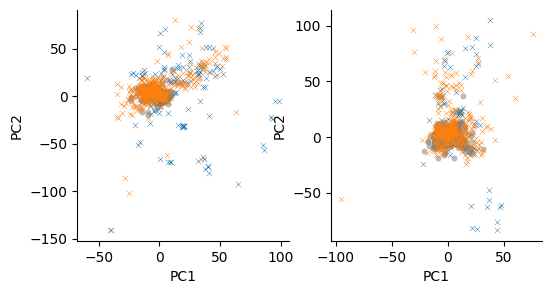

In [81]:
df = pd.read_pickle('../260202_YF-modes/coord_matrix.pkl')

topdir = '../260202_YF-modes/data_julien'
batches = ['LAU5013/YF_LAU5013_sc_WT', 'Public_Data/YF_public_pairedData_20251010']

# remove unreliable AF3 models
threshold = 0.5

for batch in batches:
    batch_short = batch.split('/')[0]
    csv_file = glob.glob(f'{topdir}/{batch}/*.csv')[0]
    df_af3_conf = pd.read_csv(csv_file)
    exclude_ids = df_af3_conf.loc[df_af3_conf['AF3_iptm_pair_mean'] < threshold, 'id'].tolist()
    df = df[~((df['batch'] == batch_short) & (df['PDB'].isin(exclude_ids)))]

# exclude experimental structures  
df = df[df['batch'] != 'exp']

# exclude weirdos
weirdos = ['tcr2669', 'tcr0099', 'tcr1145']
df = df[~((df['PDB'].isin(weirdos)) & (df['batch'] == 'LAU5013'))]

coord_matrix = df.iloc[:,8:].to_numpy()

# select different subsets of coordinates
with open("../260202_YF-modes/min_cdr_lengths.pkl", "rb") as f:
    min_cdr_lengths = pickle.load(f)

# PCA split by chain (TRA / TRB)
tra_len = 3 * sum(min_cdr_lengths['TRA'][cdr] for cdr in ['cdr1', 'cdr2', 'cdr3'])
coord_TRA = coord_matrix[:, :tra_len]
coord_TRB = coord_matrix[:, tra_len:]
print(coord_TRA.shape)
print(coord_TRB.shape)
step = 'step1'
peptide = 'LLWNGPMAV'

fig, axes = plt.subplots(1, 2, figsize=(6, 3))

for ax, coords, chain in zip(axes, [coord_TRA, coord_TRB], ['chainA_dummyB', 'dummyA_chainB']):
    pca_chain = PCA(n_components=2)
    pcs_chain = pca_chain.fit_transform(coords)

    df_pca_chain = pd.DataFrame({
        'PC1': pcs_chain[:, 0],
        'PC2': pcs_chain[:, 1],
    })

    sns.scatterplot(df_pca_chain, x='PC1', y='PC2', ax=ax, s=15, color='grey', alpha=0.5, edgecolor=None)

    # project dummy chain data
    topdir = f'dummy_chains/{step}_dummy_{peptide}/{chain}'

    df = pd.read_pickle(f'{topdir}/coord_matrix.pkl')

    coord_matrix = df.iloc[:,1:].to_numpy()
    sel_coord_matrix = coord_matrix
    pcs = pca_chain.transform(sel_coord_matrix)

    df_pca = pd.DataFrame()
    df_pca['PC1'] = pcs[:,0]
    df_pca['PC2'] = pcs[:,1]
    df_pca['PDB'] = df['id'].values

    sns.scatterplot(df_pca, x='PC1', y='PC2', ax=ax, s=15, marker='x')

    # project original pipeline data
    topdir = f'{step}_{peptide}'
    if chain == "chainA_dummyB":
        chain_name = "TRA"
    else:
        chain_name = "TRB"

    df = pd.read_pickle(f'{topdir}/coord_matrix_{chain_name}.pkl')

    coord_matrix = df.iloc[:,1:].to_numpy()
    sel_coord_matrix = coord_matrix
    pcs = pca_chain.transform(sel_coord_matrix)

    df_pca = pd.DataFrame()
    df_pca['PC1'] = pcs[:,0]
    df_pca['PC2'] = pcs[:,1]
    df_pca['PDB'] = df['id'].values

    sns.scatterplot(df_pca, x='PC1', y='PC2', ax=ax, s=15, marker='x')
    
    ax.set_xlabel(f'PC1')
    ax.set_ylabel(f'PC2')
    sns.despine()


    

(720, 48)
(720, 54)


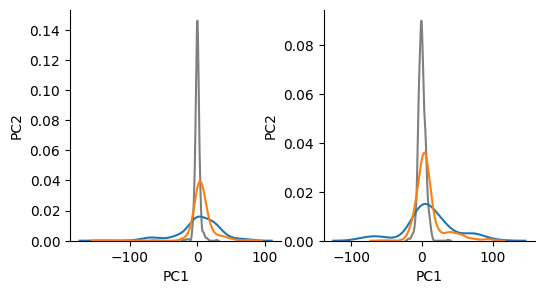

In [ ]:
df = pd.read_pickle('../260202_YF-modes/coord_matrix.pkl')

topdir = '../260202_YF-modes/data_julien'
batches = ['LAU5013/YF_LAU5013_sc_WT', 'Public_Data/YF_public_pairedData_20251010']

# remove unreliable AF3 models
threshold = 0.5

for batch in batches:
    batch_short = batch.split('/')[0]
    csv_file = glob.glob(f'{topdir}/{batch}/*.csv')[0]
    df_af3_conf = pd.read_csv(csv_file)
    exclude_ids = df_af3_conf.loc[df_af3_conf['AF3_iptm_pair_mean'] < threshold, 'id'].tolist()
    df = df[~((df['batch'] == batch_short) & (df['PDB'].isin(exclude_ids)))]

# exclude experimental structures  
df = df[df['batch'] != 'exp']

# exclude weirdos
weirdos = ['tcr2669', 'tcr0099', 'tcr1145']
df = df[~((df['PDB'].isin(weirdos)) & (df['batch'] == 'LAU5013'))]

coord_matrix = df.iloc[:,8:].to_numpy()

# select different subsets of coordinates
with open("../260202_YF-modes/min_cdr_lengths.pkl", "rb") as f:
    min_cdr_lengths = pickle.load(f)

# PCA split by chain (TRA / TRB)
tra_len = 3 * sum(min_cdr_lengths['TRA'][cdr] for cdr in ['cdr1', 'cdr2', 'cdr3'])
coord_TRA = coord_matrix[:, :tra_len]
coord_TRB = coord_matrix[:, tra_len:]
print(coord_TRA.shape)
print(coord_TRB.shape)
step = 'step1'
peptide = 'LLWNGPMAV'

fig, axes = plt.subplots(1, 2, figsize=(6, 3))

for ax, coords, chain in zip(axes, [coord_TRA, coord_TRB], ['chainA_dummyB', 'dummyA_chainB']):
    pca_chain = PCA(n_components=2)
    pcs_chain = pca_chain.fit_transform(coords)

    df_pca_chain = pd.DataFrame({
        'PC1': pcs_chain[:, 0],
        'PC2': pcs_chain[:, 1],
    })

    sns.kdeplot(df_pca_chain, x='PC1', ax=ax, color='grey')

    # project dummy chain data
    topdir = f'dummy_chains/{step}_dummy_{peptide}/{chain}'

    df = pd.read_pickle(f'{topdir}/coord_matrix.pkl')

    coord_matrix = df.iloc[:,1:].to_numpy()
    sel_coord_matrix = coord_matrix
    pcs = pca_chain.transform(sel_coord_matrix)

    df_pca = pd.DataFrame()
    df_pca['PC1'] = pcs[:,0]
    df_pca['PC2'] = pcs[:,1]
    df_pca['PDB'] = df['id'].values

    sns.kdeplot(df_pca, x='PC1', ax=ax)

    # project original pipeline data
    topdir = f'{step}_{peptide}'
    if chain == "chainA_dummyB":
        chain_name = "TRA"
    else:
        chain_name = "TRB"

    df = pd.read_pickle(f'{topdir}/coord_matrix_{chain_name}.pkl')

    coord_matrix = df.iloc[:,1:].to_numpy()
    sel_coord_matrix = coord_matrix
    pcs = pca_chain.transform(sel_coord_matrix)

    df_pca = pd.DataFrame()
    df_pca['PC1'] = pcs[:,0]
    df_pca['PC2'] = pcs[:,1]
    df_pca['PDB'] = df['id'].values

    sns.kdeplot(df_pca, x='PC1', ax=ax)
    
    ax.set_xlabel(f'PC1')
    ax.set_ylabel(f'PC2')
    sns.despine()


    

# Curate file with CDR plddts for motif annotation

In [12]:
def extract_cdr_plddt(cif_path, cdr_dict, chain_map={"TRA":"TCRA","TRB":"TCRB"}, epitope_chains=["MHC","PEPTIDE"], threshold=10):
    """
    Extract plddt of CDRs based on the respective sequences.
    """

    parser = MMCIFParser(QUIET=True)
    structure = parser.get_structure("cif", cif_path)
    model = structure[0]

    cdr_plddt = {}

    for chain_label, chain_id in chain_map.items():
        chain_obj = model[chain_id]

        residues = [res for res in chain_obj if res.id[0] == " " and "CA" in res]
        seq = "".join(seq1(res.get_resname()) for res in residues)

        cdr_dict_chain = {}
        for key, value in cdr_dict.items():
            if key.endswith(chain_id[-1]):
                cdr_dict_chain[key] = value

        for cdr, cdr_seq in cdr_dict_chain.items():
            L = len(cdr_seq)

            start_idx = seq.find(cdr_seq)
            if start_idx == -1:
                print(f"Warning: {cdr} not found in {chain_id} of {cif_path}")
                continue

            end_idx = start_idx + L

            plddts = []
            for res in residues[start_idx:end_idx]:
                res_plddts = []
                for atom in res.get_atoms():
                    res_plddts.append(atom.get_bfactor())

                mean_res_plddts = np.mean(res_plddts) / 100
                plddts.append(np.round(mean_res_plddts, 2))

            cdr_plddt[cdr] = np.array(plddts) 

    return cdr_plddt

def split_cdr3(cdr3, v_gene, j_gene, v_ref, j_ref):
    """
    Split CDR3 into V, insertion, and J sequences.
    Returns: v_seq_str, insertion_seq_str, j_seq_str
    """
    # Get reference sequences
    v_seq = v_ref.loc[v_ref['Gene']==v_gene, 'CDR3'].values
    j_seq = j_ref.loc[j_ref['Gene']==j_gene, 'CDR3'].values
    
    if len(v_seq)==0 or len(j_seq)==0:
        # If reference is missing, put everything as 'Unknown'
        return None, None
    
    v_seq = v_seq[0]
    j_seq = j_seq[0]
    
    # Match V at the start
    v_len = 0
    for i in range(min(len(v_seq), len(cdr3))):
        if cdr3[i] == v_seq[i]:
            v_len += 1
        else:
            break
    
    # Match J at the end
    j_len = 0
    for i in range(1, min(len(j_seq), len(cdr3))+1):
        if cdr3[-i] == j_seq[-i]:
            j_len += 1
        else:
            break
    
    v_part = cdr3[:v_len]
    j_part = cdr3[len(cdr3)-j_len:] if j_len > 0 else ''
    insertion_part = cdr3[v_len:len(cdr3)-j_len] if len(cdr3) > v_len + j_len else ''
    
    # drop first C and last F/W
    v_part = v_part[1:]
    j_part = j_part[:-1]

    return v_part, j_part

In [14]:
peptides = ['ELAGIGILTV', 'GILGFVFTL', 'LLWNGPMAV']

for peptide in peptides:
    topdir = f'step2_{peptide}'
    df = pd.read_csv(f'{topdir}/chainA_B_random_pair_{peptide}_output.txt', delim_whitespace=True)[['id', 'AF3_iptm_pair_mean']]
    anno = pd.read_csv(f'{topdir}/chainA_B_random_pair_{peptide}_input.txt', delim_whitespace=True)
    df = pd.merge(df, anno, on='id')
    df = df[df['AF3_iptm_pair_mean'] > 0.8]
    df = df.rename(columns={'cdr3_TRA' : 'CDR3A', 'cdr3_TRB' : 'CDR3B'})

    genes = ['TRAV', 'TRBV']
    for gene in genes:
        anno = pd.read_csv(f'../MixTCRviz/data_raw/HomoSapiens/{gene}.csv')
        anno = anno.rename(columns={anno.columns[0]:gene})

        anno[f'CDR1{gene[-2]}'] = anno['CDR1'].str.replace('-', '', regex=False)
        anno[f'CDR2{gene[-2]}'] = anno['CDR2'].str.replace('-', '', regex=False)
        anno = anno[[gene, f'CDR1{gene[-2]}', f'CDR2{gene[-2]}']]

        df = pd.merge(df, anno, on=gene)

    # reference dataframes to split cdr3 according to V/J contributions
    TRAV_ref = pd.read_csv(f'../MixTCRviz/data_raw/HomoSapiens/TRAV.csv').rename(columns={'Unnamed: 0':'Gene'})
    TRAJ_ref = pd.read_csv(f'../MixTCRviz/data_raw/HomoSapiens/TRAJ.csv').rename(columns={'Unnamed: 0':'Gene'})
    TRBV_ref = pd.read_csv(f'../MixTCRviz/data_raw/HomoSapiens/TRBV.csv').rename(columns={'Unnamed: 0':'Gene'})
    TRBJ_ref = pd.read_csv(f'../MixTCRviz/data_raw/HomoSapiens/TRBJ.csv').rename(columns={'Unnamed: 0':'Gene'})

    lst = []
    for idx, row in df.iterrows():
        cdr_dict = {cdr: str(row[cdr]).upper() for cdr in ["CDR1A","CDR2A","CDR3A","CDR1B","CDR2B","CDR3B"]}

        file = f'{topdir}/AF3_outputs/{row.id}/{row.id}_model.cif'
        
        cdr_plddts = extract_cdr_plddt(file, cdr_dict, chain_map={"TRA":"TCRA","TRB":"TCRB"}, epitope_chains=["MHC","PEPTIDE"])
        
        # add cdr3 v/j part
        v_part, j_part = split_cdr3(row.CDR3A, row.TRAV, row.TRAJ, TRAV_ref, TRAJ_ref)
        cdr_plddts['CDR3AV'] = cdr_plddts['CDR3A'][:len(v_part)]
        cdr_plddts['CDR3AJ'] = cdr_plddts['CDR3A'][-len(j_part):]

        v_part, j_part = split_cdr3(row.CDR3B, row.TRBV, row.TRBJ, TRBV_ref, TRBJ_ref)
        cdr_plddts['CDR3BV'] = cdr_plddts['CDR3B'][:len(v_part)]
        cdr_plddts['CDR3BJ'] = cdr_plddts['CDR3B'][-len(j_part):]

        cdr_plddts['id'] = row.id
        cdr_plddts['TRAV'] = row.TRAV
        cdr_plddts['TRAJ'] = row.TRAJ
        cdr_plddts['TRBV'] = row.TRBV
        cdr_plddts['TRBJ'] = row.TRBJ
        cdr_plddts['CDR3A_seq'] = row.CDR3A
        cdr_plddts['CDR3B_seq'] = row.CDR3B
        lst.append(cdr_plddts)

    df = pd.DataFrame(lst)   
    df.to_csv(f'{topdir}/cdr_plddts.csv', index=False)

/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_95793/4032854266.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(f'{topdir}/chainA_B_random_pair_{peptide}_output.txt', delim_whitespace=True)[['id', 'AF3_iptm_pair_mean']]
/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_95793/4032854266.py:6: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  anno = pd.read_csv(f'{topdir}/chainA_B_random_pair_{peptide}_input.txt', delim_whitespace=True)
/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_95793/4032854266.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(f'{topdir}/chainA_B_random_pair_{peptide}_output.txt', delim_whitespace=True)[['id',